# Assignment 1: Feature Extraction and Deep Learning for Images
## Section 1: Histogram of Oriented Gradients (HOG) & Object Detection

### Prasanna Paithankar (21CS30065)

4th February 2026

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.svm import SVC

### (a) Compute HOG Features

In [2]:
class HOG_v1:
    def __init__(self, cell_size=(8, 8), block_size=(2, 2), nbins=9):
        self.cell_size = cell_size
        self.block_size = block_size
        self.nbins = nbins

    def compute_gradients(self, img):
        if len(img.shape) == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img

        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=1)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=1)

        magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
        angle = angle % 180
        return magnitude, angle

    def get_hog_features(self, img, visualize=False):
        magnitude, angle = self.compute_gradients(img)
        h, w = magnitude.shape
        cell_h, cell_w = self.cell_size

        n_cells_y = h // cell_h
        n_cells_x = w // cell_w
        histograms = np.zeros((n_cells_y, n_cells_x, self.nbins))

        for i in range(n_cells_y):
            for j in range(n_cells_x):
                cell_mag = magnitude[
                    i * cell_h : (i + 1) * cell_h, j * cell_w : (j + 1) * cell_w
                ]
                cell_ang = angle[
                    i * cell_h : (i + 1) * cell_h, j * cell_w : (j + 1) * cell_w
                ]

                for k in range(self.nbins):
                    bin_range_min = k * (180 / self.nbins)
                    bin_range_max = (k + 1) * (180 / self.nbins)

                    mask = (cell_ang >= bin_range_min) & (cell_ang < bin_range_max)
                    histograms[i, j, k] = np.sum(cell_mag[mask])

        block_h, block_w = self.block_size
        n_blocks_y = n_cells_y - block_h + 1
        n_blocks_x = n_cells_x - block_w + 1
        normalized_blocks = []

        for i in range(n_blocks_y):
            for j in range(n_blocks_x):
                block = histograms[i : i + block_h, j : j + block_w, :].flatten()
                block = block / np.sqrt(np.sum(block**2) + 1e-5)
                normalized_blocks.append(block)

        features = np.array(normalized_blocks).flatten()

        if visualize:
            return features, self.visualize_hog(img, histograms)
        return features

    def visualize_hog(self, img, histograms):
        h, w = img.shape[:2]
        cell_h, cell_w = self.cell_size
        vis_img = np.zeros((h, w), dtype=np.uint8)
        n_cells_y, n_cells_x, _ = histograms.shape
        max_mag = np.max(histograms) + 1e-5

        for i in range(n_cells_y):
            for j in range(n_cells_x):
                cx, cy = j * cell_w + cell_w // 2, i * cell_h + cell_h // 2

                for k in range(self.nbins):
                    mag = histograms[i, j, k]
                    if mag > 0:
                        angle_deg = k * (180 / self.nbins) + (90 / self.nbins)
                        angle_rad = np.deg2rad(angle_deg)
                        length = int((mag / max_mag) * cell_w)

                        x1 = int(cx - length * np.cos(angle_rad + np.pi / 2))
                        y1 = int(cy - length * np.sin(angle_rad + np.pi / 2))
                        x2 = int(cx + length * np.cos(angle_rad + np.pi / 2))
                        y2 = int(cy + length * np.sin(angle_rad + np.pi / 2))

                        cv2.line(
                            vis_img, (x1, y1), (x2, y2), int(255 * (mag / max_mag)), 1
                        )
        return vis_img

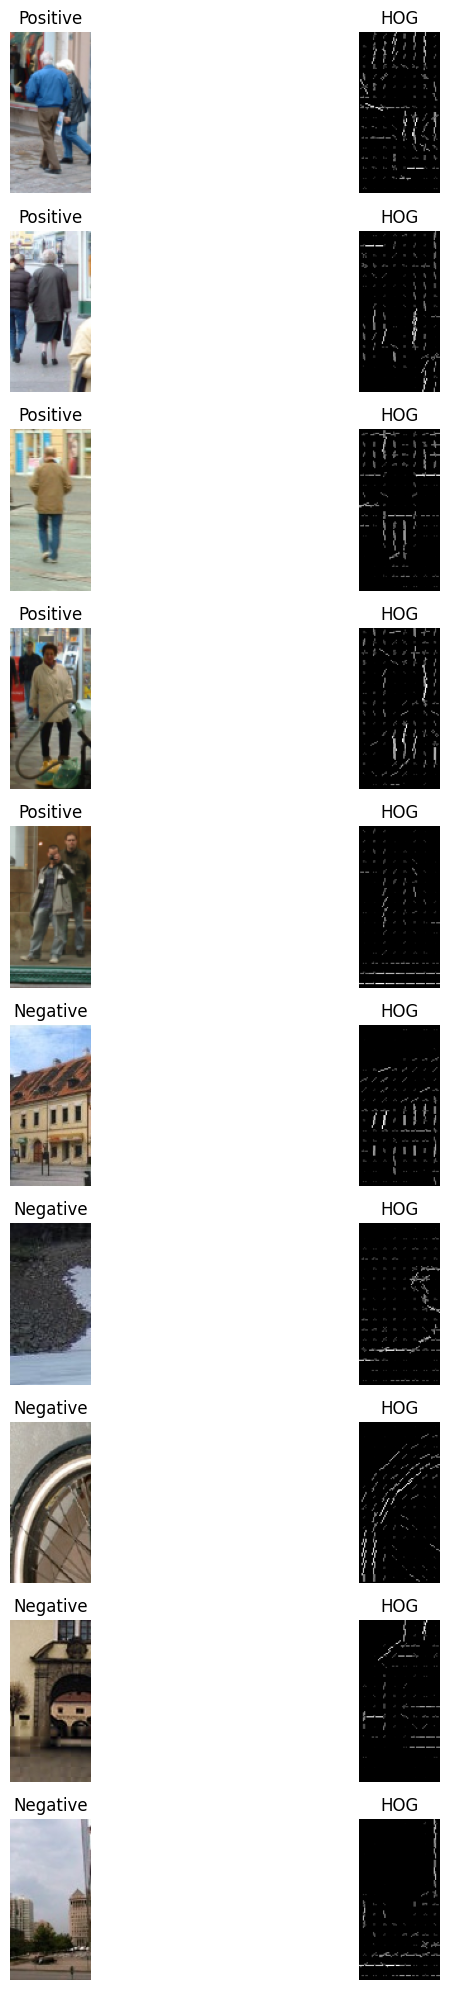

In [3]:
hog_extractor = HOG_v1(cell_size=(8, 8), block_size=(2, 2), nbins=9)


def load_and_resize(path, size=(64, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.resize(img, size)


pos_paths = glob.glob("pedestrian_detection_images/positive/*")[:5]
neg_paths = glob.glob("pedestrian_detection_images/negative/*")[:5]

plt.figure(figsize=(10, 20))

all_paths = pos_paths + neg_paths

for idx, p in enumerate(all_paths):
    img = load_and_resize(p)
    if img is not None:
        _, vis = hog_extractor.get_hog_features(img, visualize=True)

        plt.subplot(10, 2, idx * 2 + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Positive" if idx < 5 else "Negative")
        plt.axis("off")

        plt.subplot(10, 2, idx * 2 + 2)
        plt.imshow(vis, cmap="gray")
        plt.title("HOG")
        plt.axis("off")

plt.tight_layout()
plt.show()

### (b) Pedestrian Detection

In [4]:
def prepare_data(folder, label, limit=None):
    features = []
    labels = []
    paths = glob.glob(f"pedestrian_detection_images/{folder}/*")
    if limit:
        paths = paths[:limit]

    for path in paths:
        img = load_and_resize(path)
        if img is not None:
            feat = hog_extractor.get_hog_features(img, visualize=False)
            features.append(feat)
            labels.append(label)
    return features, labels


pos_feats, pos_labels = prepare_data("positive", 1)
neg_feats, neg_labels = prepare_data("negative", 0)

X_train = np.array(pos_feats + neg_feats)
y_train = np.array(pos_labels + neg_labels)

print("Training Linear SVM ")
svm = SVC(kernel="linear")
svm.fit(X_train, y_train)
train_preds = svm.predict(X_train)
train_accuracy = np.mean(train_preds == y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

Training Linear SVM 
Training Accuracy: 100.00%


Test Accuracy: 100.00%


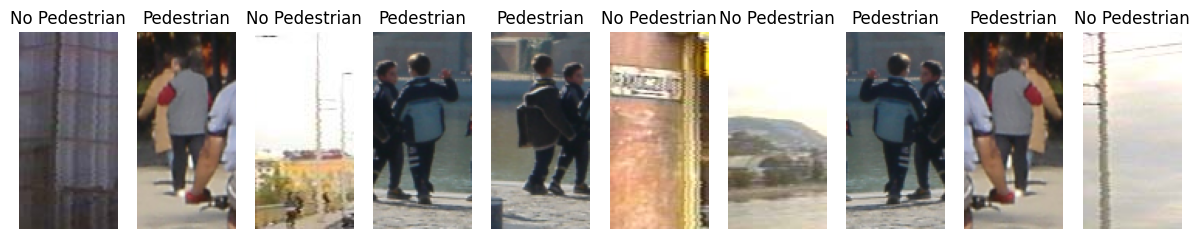

In [5]:
test_paths = glob.glob("pedestrian_detection_images/test/*")
test_accuracy_list = []

plt.figure(figsize=(15, 4))
for i, path in enumerate(test_paths):
    img = load_and_resize(path)
    if img is not None:
        feat = hog_extractor.get_hog_features(img, visualize=False).reshape(1, -1)

        prediction = svm.predict(feat)[0]
        label_text = "Pedestrian" if prediction == 1 else "No Pedestrian"
        if "crop" in path:
            actual_label = "Pedestrian"
        else:
            actual_label = "No Pedestrian"
        if actual_label == label_text:
            test_accuracy_list.append(1)
        else:
            test_accuracy_list.append(0)

        plt.subplot(1, 10, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(label_text)
        plt.axis("off")

test_accuracy = np.mean(test_accuracy_list)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
plt.show()

***